In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Set random seed for reproducibility
np.random.seed(0)
tf.random.set_seed(0)

In [3]:
# Generate a non-linear dataset (moons)
X, y = make_moons(n_samples=1000, noise=0.1, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [4]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model WITHOUT activation functions (linear)
model_without_activation = Sequential([
    Dense(16, input_shape=(2,)),  # No activation function
    Dense(8),                     # No activation function
    Dense(1, activation='sigmoid')  # Only output layer has activation for binary classification
])

# Model WITH activation functions
model_with_activation = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile both models
model_without_activation.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_with_activation.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train both models
history_without = model_without_activation.fit(
    X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0
)
history_with = model_with_activation.fit(
    X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0
)

# Evaluate both models
_, acc_without = model_without_activation.evaluate(X_test, y_test, verbose=0)
_, acc_with = model_with_activation.evaluate(X_test, y_test, verbose=0)

print(f"Test accuracy WITHOUT activation functions: {acc_without:.4f}")
print(f"Test accuracy WITH activation functions: {acc_with:.4f}")



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test accuracy WITHOUT activation functions: 0.8750
Test accuracy WITH activation functions: 0.9600


In [5]:
# Plot decision boundaries
def plot_decision_boundary(model, X, y, title):
    # Create a mesh grid on which we will run our model
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Make predictions on the meshgrid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0)
    Z = Z.reshape(xx.shape)

    # Plot the decision boundary
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdBu)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')



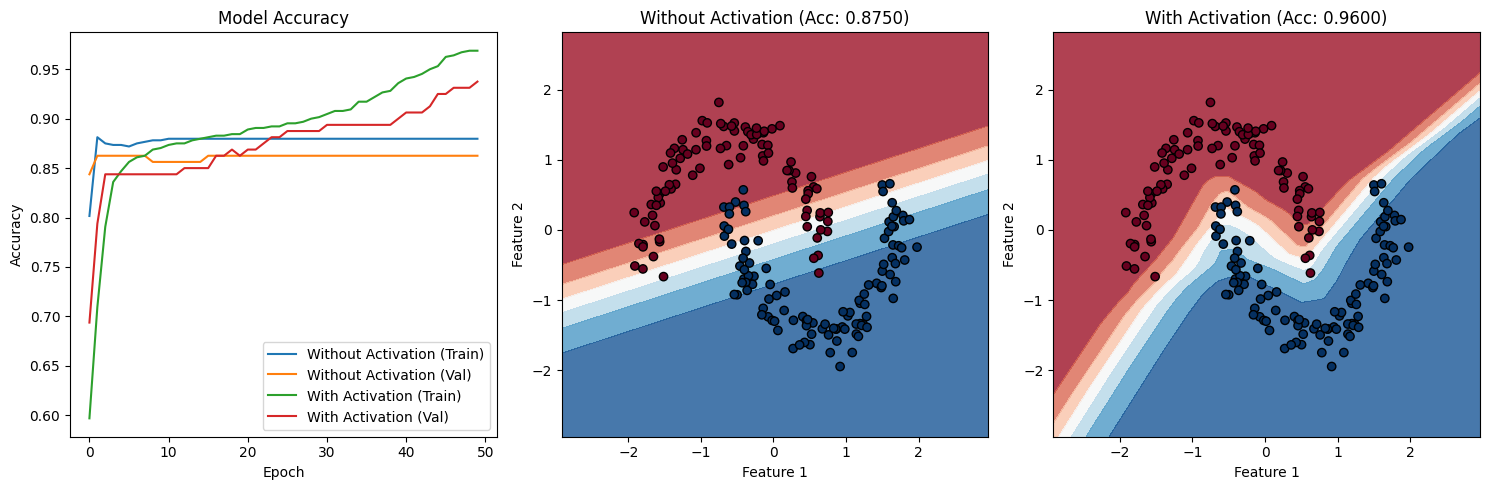


Why activation functions are important:
1. Non-linearity: Without activation functions, deep networks reduce to a single linear transformation,
   regardless of depth. Activation functions introduce non-linearity, allowing networks to learn
   complex patterns and relationships.
2. Representation power: Neural networks with activations are universal function approximators, meaning
   they can approximate any continuous function given enough neurons.
3. Feature learning: In deep networks, activation functions help learn hierarchical features at different
   levels of abstraction.
4. Gradient flow: Appropriate activation functions help with better gradient flow during backpropagation,
   addressing issues like vanishing/exploding gradients.


In [6]:
# Plot learning curves
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_without.history['accuracy'], label='Without Activation (Train)')
plt.plot(history_without.history['val_accuracy'], label='Without Activation (Val)')
plt.plot(history_with.history['accuracy'], label='With Activation (Train)')
plt.plot(history_with.history['val_accuracy'], label='With Activation (Val)')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# Plot decision boundaries
plt.subplot(1, 3, 2)
plot_decision_boundary(model_without_activation, X_test, y_test,
                       f'Without Activation (Acc: {acc_without:.4f})')

plt.subplot(1, 3, 3)
plot_decision_boundary(model_with_activation, X_test, y_test,
                       f'With Activation (Acc: {acc_with:.4f})')

plt.tight_layout()
plt.savefig('activation_function_comparison.png')
plt.show()

# Explain why activation functions are important
print("\nWhy activation functions are important:")
print("1. Non-linearity: Without activation functions, deep networks reduce to a single linear transformation,")
print("   regardless of depth. Activation functions introduce non-linearity, allowing networks to learn")
print("   complex patterns and relationships.")
print("2. Representation power: Neural networks with activations are universal function approximators, meaning")
print("   they can approximate any continuous function given enough neurons.")
print("3. Feature learning: In deep networks, activation functions help learn hierarchical features at different")
print("   levels of abstraction.")
print("4. Gradient flow: Appropriate activation functions help with better gradient flow during backpropagation,")
print("   addressing issues like vanishing/exploding gradients.")